# Multifactor Dispersion Bias — Theorem Part (ii): End-to-End Walkthrough

This notebook runs the numerical verification of **Equation (6), Part (ii)** of
*Multifactor Dispersion Bias with Per-Column Prevalence* (diagonal-Gram case,
$G_\infty = I_k$) from configuration through to figures, and doubles as
documentation of the orchestrator refactor.

For each factor $j$, as $p \to \infty$ (conditional on $F$, almost surely):

$$\sin^2\angle(h_j, \bar b_j) \;\longrightarrow\;
\underbrace{\frac{\delta^2}{n\rho_j + \delta^2}}_{\text{floor}}
\;+\;
\underbrace{\frac{n\rho_j}{n\rho_j + \delta^2}}_{\text{weight}}\cdot
\underbrace{\sin^2\angle(\hat w_j, e_j)}_{\text{rotation}}$$

The verification computes the **LHS** (observed $\sin^2$ from simulated returns)
and the **RHS** (predicted from the realized factor returns), and confirms the
gap between them shrinks to zero as the ambient dimension $p$ grows.

## Why this notebook is short: the coupling problem and the refactor

**Before the refactor**, all of the logic lived inside a single `simulate()`
function in `sim_theorem_partii.py` — a triple-nested loop where four distinct
stages were *braided together*:

```python
# OLD shape (illustrative — not the current code):
def simulate(spec):
    rng = np.random.default_rng(spec.random_seed)
    records = []
    for n in spec.n_values:
        for p in spec.p_values:
            model = build_model(spec, p, rng)            # model construction
            _, b_pop = compute_true_eigenvalues(model, k)
            for r in range(spec.n_reps):
                sim_out = simulator.simulate(model, n, ...)   # return sampling
                context = SimulationContext(model, ...)
                lhs = SineAlignmentAnalysis(b_pop).analyze(context)  # analysis
                rhs = Eq6RHSAnalysis().analyze(context)              # (hardcoded)
                records.extend(...)
    return pd.DataFrame(records)
```

Because model construction, return sampling, and analysis were interleaved in one
function with shared local state, you **could not**: build a model once and run
several return distributions against it; swap the set of analyses without editing
the loop; or call any single stage from a notebook without copy-pasting the whole
body. The plotting layer was similarly study-specific and not reusable.

**After the refactor**, the machinery is split into three layers, and each stage
is an importable function with explicit inputs and outputs:

| Stage | Function | Lives in |
|---|---|---|
| 1 — model construction | `build_model(model_spec, p, rng)` | `fl_experiment.py` |
| 2–4 — return sampling | `simulate_returns(model, n, …, rep_rng)` | `fl_orchestration.py` |
| analysis dispatch | `run_analyses(context, [analysis, …])` | `fl_orchestration.py` |
| per-cell driver | `run_cell(model_spec, design_spec, experiment, n, p, rng)` | `fl_experiment.py` |
| engine | `run_experiment(model_spec, design_spec, experiment)` | `fl_experiment.py` |
| probe (what to measure) | `DispersionBiasExperiment` | `sim_theorem_partii.py` |

The **engine** (`fl_experiment`) is theorem-agnostic — it just owns the sweep and
the master-RNG draw order. The **probe** (`sim_theorem_partii`) is the only
theorem-specific piece: a small `Experiment` with three hooks (`setup`,
`cell_setup`, `record`). A new theorem is a new `Experiment` handed to the same
`run_experiment`; no engine change. Two companion changes ride along:

- **Config** — `ModelSpec` (what defines the factor model) and `DesignSpec` (the
  sweep + return process). The design carries its model in one `model` field
  (path / inline / folded-from-top-level), so one model is reusable across
  designs. There is no separate unified spec class.
- **Visualization harness** — `fl_visualization.py` provides a generic figure
  registry/dispatch; `fl_graphics.py` registers the dispersion-bias figures into
  it. New figures register without touching the harness.

**The payoff is exactly this notebook:** every cell below is a thin *caller* that
imports these functions. The notebook does not re-implement anything — the same
functions back the CLI script and any future script or notebook.

> **Two invariants the refactor preserves.** `run_cell` is the sole owner of the
> master-RNG draw order (model draws → per-rep seeds → independent child
> generators), so output is **bit-identical** across the unified, split, and
> notebook entry points. And the verification keeps redrawing $\beta$ **fresh
> every $(n,p)$ cell** — the conditional-on-$F$ regime the Part-(ii) claim is
> stated under.

## Setup

The notebook lives at the repo root, next to the modules it imports. The cell
below puts the repo root on `sys.path` and imports the public surface — this
import working cleanly *is* the importability the refactor was after.

In [1]:
import sys
from pathlib import Path

# Repo root = this notebook's directory; put it on sys.path so the modules import.
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
from loguru import logger

# Quiet the loguru INFO/DEBUG chatter for a clean notebook (raise to "INFO" to
# watch the pipeline's stage logs).
logger.remove()
logger.add(sys.stderr, level="WARNING")

# Public surface, three layers:
#   fl_experiment      — the generic engine (specs, Experiment protocol, runner)
#   fl_orchestration   — dispersion-agnostic seams
#   sim_theorem_partii — the dispersion-bias probe (analyses + Experiment)
from fl_experiment import ModelSpec, DesignSpec, build_model, run_cell, run_experiment
from sim_theorem_partii import (
    DispersionBiasExperiment, simulate, print_summary,
    SineAlignmentAnalysis, Eq6RHSAnalysis,
)
from factor_lab.analyses.spectral import compute_true_eigenvalues
from fl_orchestration import simulate_returns, run_analyses
from fl_graphics import plot_all
import fl_visualization as viz

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)
print("Imports OK. Output dir:", OUT_DIR)

Imports OK. Output dir: /Users/alex/Documents/Finance_Projects/factor_lab/nb_outputs


## Step 1 — Configuration (model + design)

A run is two pieces. A **`ModelSpec`** owns what defines the factor model — number
of factors, factor variances, loading samplers, idiosyncratic-vol sampler. A
**`DesignSpec`** owns the sweep and return process — the $n$/$p$ grids,
replications, seed, return samplers, output.

The design carries its model in its `model` field, which may be a **path
reference** (`"model_spec.example.json"`), an **inline object**, or — for a single
self-contained file — model fields written at the JSON **top level** (folded in by
`DesignSpec.from_json`). `resolve_model()` turns any of those into a concrete
`ModelSpec`. There is no separate unified spec class; one model can be reused
across many designs.

In [2]:
# A run is a ModelSpec + a DesignSpec. The split-config example files compose to
# exactly the built-in defaults: the design references the model by path, and
# resolve_model() loads it.
from dataclasses import asdict

design_from_file = DesignSpec.from_json("experiment_spec.example.json")
model_from_file = design_from_file.resolve_model(REPO_ROOT)
assert asdict(model_from_file) == asdict(ModelSpec())
assert design_from_file.n_values == DesignSpec().n_values
print("Split-config files compose to the built-in defaults  ✓")

# The model: canonical diagonal-Gram model (cⱼ=[1.0,0.8,0.6], σ²=[.04,.02,.01]).
model_spec = ModelSpec()

# The design: a small *smoke* sweep — fast, but the RMSE-falls-with-p trend is
# already visible. Swap in DesignSpec() (commented) for the full canonical run
# (16,200 rows, several minutes).
design_spec = DesignSpec(
    n_values=[30, 60],
    p_values=[200, 500, 1000, 3000],
    n_reps=40,
    random_seed=20260511,
)
# design_spec = DesignSpec()   # <- full canonical experiment

print(f"k={model_spec.k_factors}, n={design_spec.n_values}, p={design_spec.p_values}, "
      f"reps={design_spec.n_reps}, seed={design_spec.random_seed}")

Split-config files compose to the built-in defaults  ✓
k=3, n=[30, 60], p=[200, 500, 1000, 3000], reps=40, seed=20260511


## Step 2 — The decoupled pipeline, one stage at a time

This is what `run_cell` does internally for a single replication, unrolled so the
seams are visible. Each call below is an importable function from the refactor.

**Stage 1 — `build_model`.** Construct one factor model $(B, F, D)$ for a
given $(n, p)$ cell. `B` is $(k, p)$, `F = diag(\sigma_j^2)`, `D` holds
idiosyncratic *variances*.

In [3]:
rng = np.random.default_rng(design_spec.random_seed)
n_demo, p_demo = 60, 1000

model = build_model(model_spec, p_demo, rng)
print("B shape:", model.B.shape, "  (k, p)")
print("F diag :", np.round(np.diag(model.F), 4))
print("delta^2:", round(float(np.diag(model.D).mean()), 4), " (mean idio variance)")
print("empirical prevalences c_j =||B[j]||^2/p:",
      np.round((model.B ** 2).mean(axis=1), 3))

B shape: (3, 1000)   (k, p)
F diag : [0.04 0.02 0.01]
delta^2: 1.0  (mean idio variance)
empirical prevalences c_j =||B[j]||^2/p: [0.947 0.801 0.575]


**Population directions, then Stages 2–4 + analysis dispatch.** The
population loading directions $\bar b_j$ (top-$k$ eigenvectors of
$\Sigma_0 = B\Sigma_F B^\top/p$) are computed once per cell. Then
`simulate_returns` samples one replication's returns into a `SimulationContext`,
and `run_analyses` dispatches the LHS and RHS analyses over it — note the
analyses are passed in *as a list*, not hardcoded.

In [4]:
# Population directions (ARPACK), computed once per cell. This is exactly what
# DispersionBiasExperiment.cell_setup(model, n, p) does — it returns the analyses
# below paired with these b_pop directions.
_, b_pop = compute_true_eigenvalues(model, model_spec.k_factors)

# Stages 2-4: one replication of returns, drawn from an independent child RNG.
rep_rng = np.random.default_rng(12345)
context = simulate_returns(
    model=model, n=n_demo,
    factor_return_spec=design_spec.factor_return_sampler,
    idio_return_spec=design_spec.idio_return_sampler,
    k=model_spec.k_factors, rep_rng=rep_rng,
)

# Analysis dispatch: a list of analyses, merged into one result dict. The probe
# supplies exactly this list from cell_setup; swapping it is how a new theorem
# plugs in.
analyses = [SineAlignmentAnalysis(b_pop), Eq6RHSAnalysis()]
res = run_analyses(context, analyses)

print("LHS observed  sin^2(h_j, b_j):", np.round(res["sin2_j"], 4))
print("RHS predicted               :", np.round(res["rhs"], 4))
print("  floor   :", np.round(res["floor"], 4))
print("  rotation:", np.round(res["rotation"], 4))
print("gap (LHS - RHS):", np.round(res["sin2_j"] - res["rhs"], 4))

LHS observed  sin^2(h_j, b_j): [0.3138 0.651  0.9074]
RHS predicted               : [0.3138 0.5849 0.7824]
  floor   : [0.3013 0.5618 0.774 ]
  rotation: [0.0179 0.0527 0.037 ]
gap (LHS - RHS): [-0.      0.0661  0.125 ]


## Step 3 — Run the full sweep end to end

`run_experiment(model, design, experiment)` is the engine: it seeds the master
RNG from the design, loops `run_cell` over every $(n, p)$ cell — preserving the
draw order so output is reproducible — and returns a tidy per-replication
DataFrame. The probe (`DispersionBiasExperiment`) supplies *what to measure*; the
engine knows nothing about the theorem. `simulate(design)` is the one-call
shortcut that resolves the model and calls the engine for you.

In [5]:
# run_experiment(model, design, probe) is the engine: it owns the master-RNG draw
# order, sweeps every (n, p) cell via run_cell, and concatenates to a tidy frame.
df = run_experiment(model_spec, design_spec, DispersionBiasExperiment())

# Equivalent one-call shortcut when the design carries its own model (inline /
# referenced / folded): df = simulate(design_spec)

print("rows:", len(df), " columns:", list(df.columns))
df.head()

n=30:   0%|          | 0/4 [00:00<?, ?p/s]

n=30: 100%|██████████| 4/4 [00:00<00:00, 66.49p/s]

n=60:   0%|          | 0/4 [00:00<?, ?p/s]

n=60: 100%|██████████| 4/4 [00:00<00:00, 42.13p/s]

rows: 960  columns: ['n', 'p', 'j', 'sin2_j', 'rhs', 'gap', 'floor', 'rotation', 'rho']


,n,p,j,sin2_j,rhs,gap,floor,rotation,rho
0,30,200,1,0.742917,0.624593,0.118324,0.545949,0.173205,0.027722
1,30,200,2,0.889252,0.654559,0.234692,0.593438,0.150338,0.022837
2,30,200,3,0.999501,0.867136,0.132365,0.863557,0.026238,0.005267
3,30,200,1,0.492615,0.460233,0.032382,0.454906,0.009773,0.039942
4,30,200,2,0.954002,0.775136,0.178867,0.771840,0.014445,0.009854


## Step 4 — Results: the theorem confirmation

The RMSE of $(\sin^2\angle - \text{RHS})$ per $(n, p, j)$ should **decrease as $p$
grows** — that decline is the numerical confirmation of the theorem.

In [6]:
print_summary(df)


RMSE of (sin²∠ − RHS)  [smaller is better; should → 0 as p grows]

            j=1     j=2     j=3
n  p                           
30 200  0.13281 0.19238 0.10178
   500  0.04173 0.12424 0.10989
   1000 0.02801 0.05734 0.08890
   3000 0.01715 0.02243 0.06165
60 200  0.08702 0.21337 0.19928
   500  0.03779 0.07183 0.19351
   1000 0.01904 0.03988 0.14527
   3000 0.01056 0.01810 0.05391



## Step 5 — Visualization: the reusable harness

`fl_graphics.py` holds the study-specific figures (gap-convergence,
LHS-vs-RHS scatter, floor/rotation components) and **registers** them into the
generic `fl_visualization` harness. `plot_all` is a thin wrapper over
`render_figures`; the harness itself is dispersion-agnostic.

(`fl_graphics` forces the non-interactive Agg backend, so figures are written to
disk and displayed inline below.)

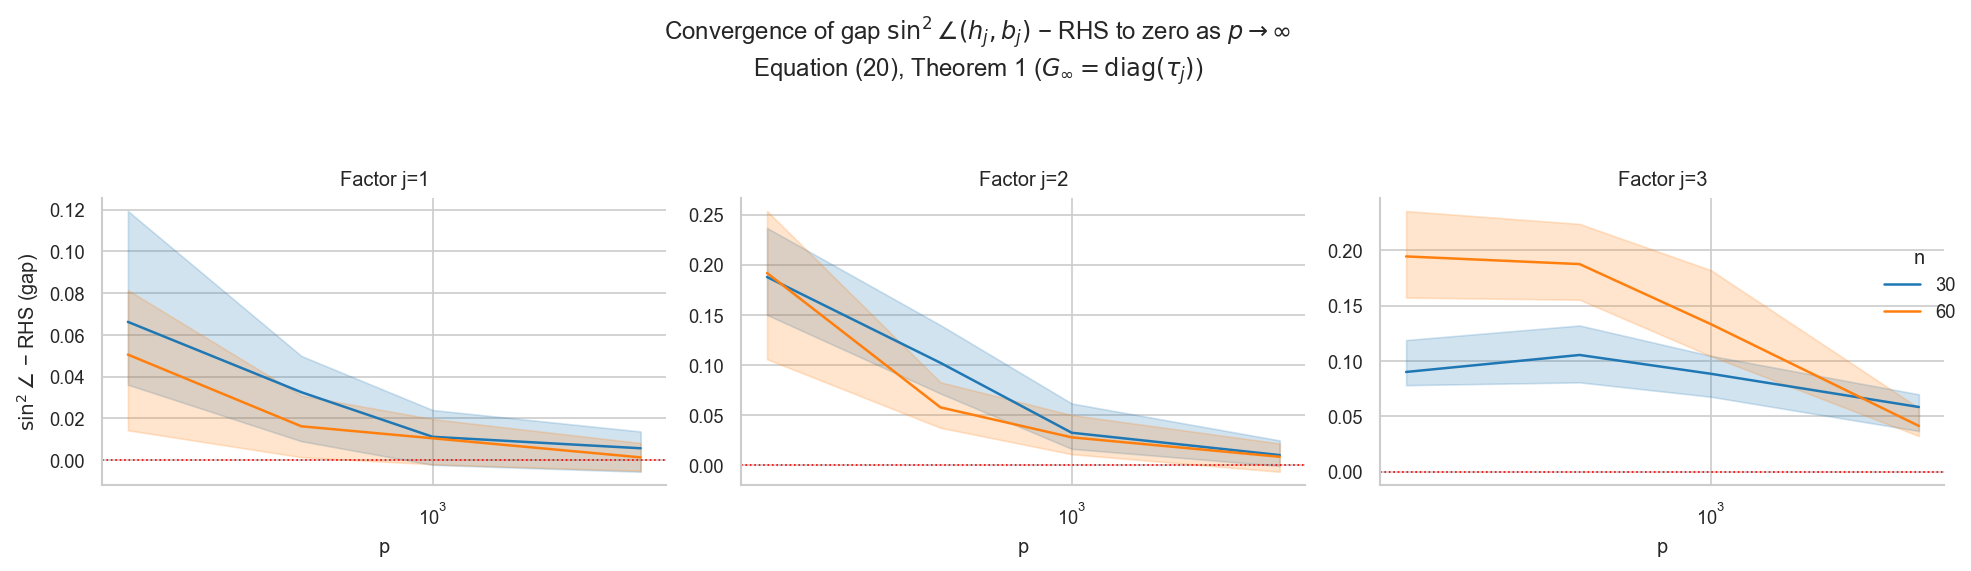

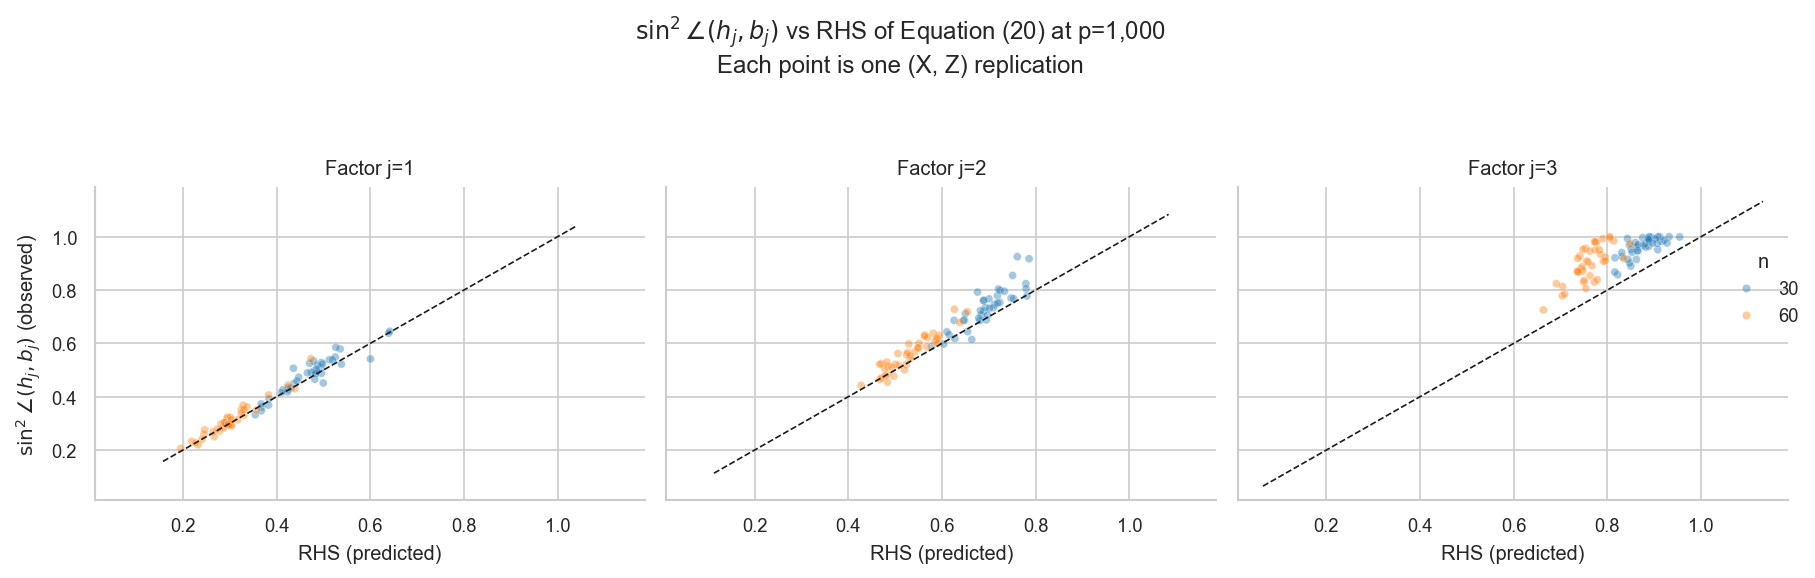

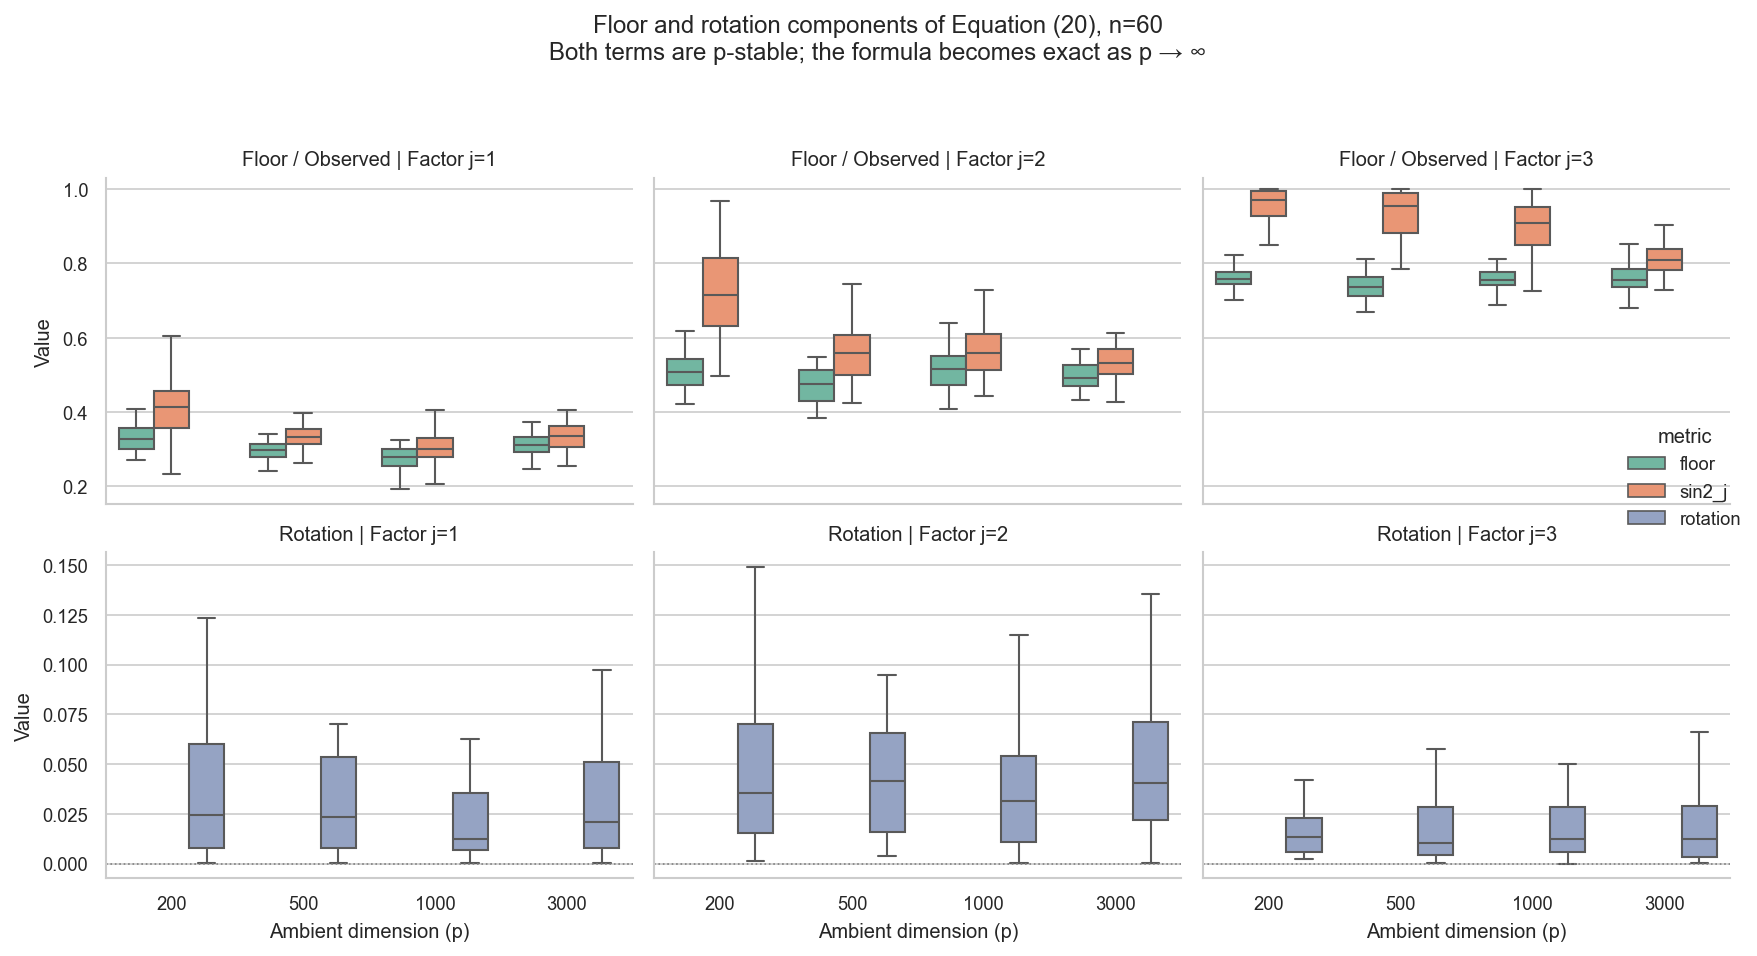

In [7]:
from IPython.display import Image, display

plot_all(df, OUT_DIR, n_show=60)

for fname in ["fig_theorem1_convergence_v2.png",
              "fig_theorem1_scatter_v2.png",
              "fig_theorem1_components_v2.png"]:
    display(Image(filename=str(OUT_DIR / fname)))

**Extending the harness without touching it.** A future study registers its
own figure and renders it through the same `render_figures` entry point — no edit
to `fl_visualization.py`. Here is an ad-hoc figure registered and rendered live:

registered figures: ['theorem1_convergence', 'theorem1_scatter', 'theorem1_components', 'gap_hist']


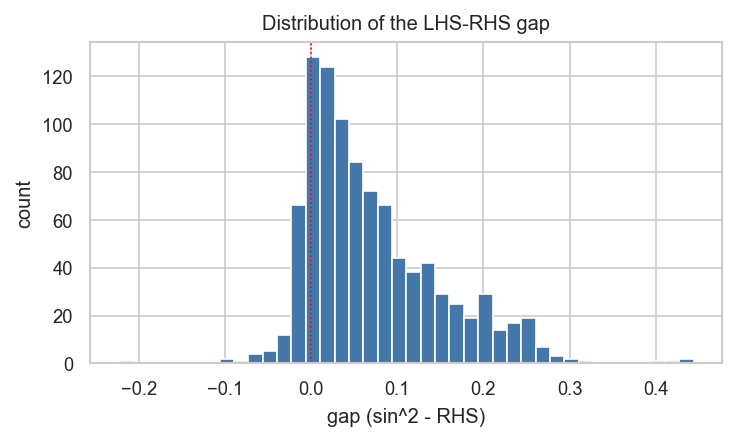

In [8]:
import matplotlib.pyplot as plt

def gap_hist(df, out_path, **kwargs):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(df["gap"], bins=40, color="#4477aa")
    ax.axvline(0, color="red", linestyle=":", linewidth=0.8)
    ax.set_xlabel("gap (sin^2 - RHS)"); ax.set_ylabel("count")
    ax.set_title("Distribution of the LHS-RHS gap")
    viz.save_fig(fig, out_path)

viz.register_figure("gap_hist", gap_hist, "fig_gap_hist.png")
print("registered figures:", viz.registered_figures())

produced = viz.render_figures(df, OUT_DIR, names=["gap_hist"])
display(Image(filename=str(produced["gap_hist"])))

## Running the full canonical experiment

The cell in Step 1 used a small smoke design. For the full verification, either
swap in `design_spec = DesignSpec()` above and re-run, or run the script from the
command line (which writes a parquet + the three figures to
`results/MM-DD_run_NN/`):

```bash
# Built-in defaults
python sim_theorem_partii.py --plot-save

# Single self-contained file (model folded inline)
python sim_theorem_partii.py sim_thmptii_spec.json --plot-save

# Design referencing a model, with optional --model override
python sim_theorem_partii.py experiment_spec.example.json --plot-save
python sim_theorem_partii.py experiment_spec.example.json --model model_spec.example.json --plot-save
```

The canonical config is $3$ factors $\times\, 300$ reps $\times\, 6$ $p$-values
($200\ldots10{,}000$) $\times\, 3$ $n$-values $= 16{,}200$ rows and takes several
minutes.

## Refactor surface (quick reference)

| File | Role |
|---|---|
| `fl_orchestration.py` | Dispersion-agnostic seams: `simulate_returns`, `run_analyses`, sampler resolution, run-dir allocator. |
| `fl_experiment.py` | Generic engine: `ModelSpec`, `DesignSpec`, the `Experiment` protocol, `build_model`, `run_cell`, `run_experiment`. |
| `sim_theorem_partii.py` | Dispersion-bias probe: the two analyses, `DispersionBiasExperiment`, `simulate`, `main` (CLI). |
| `fl_visualization.py` | Generic figure harness: `register_figure`, `render_figures`, IO/styling helpers. |
| `fl_graphics.py` | Dispersion-bias figures, registered into the harness; `plot_all`. |
| `model_spec.example.json` / `experiment_spec.example.json` | Split-config example pair that reproduces the default run. |

Verified: a 71-test suite passes (99% line coverage across the three orchestration
modules), and engine output is bit-identical across the defaults, the unified
single-file shape, the split (model + design) shape, and the `--model` override.